# Tutorial: Serial Agent Workflows with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0`
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 1_Sequential_Pattern.ipynb`

This walkthrough demonstrates how to build and orchestrate a `Serial/Sequential pipeline` of agents using the **AgentGrid SDKs**. We focus on the **Meeting Agenda Agents** flow: Brainstormer ➡️ Architect ➡️ Invitation Crafter.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

## AgentGrid High Level Diagram
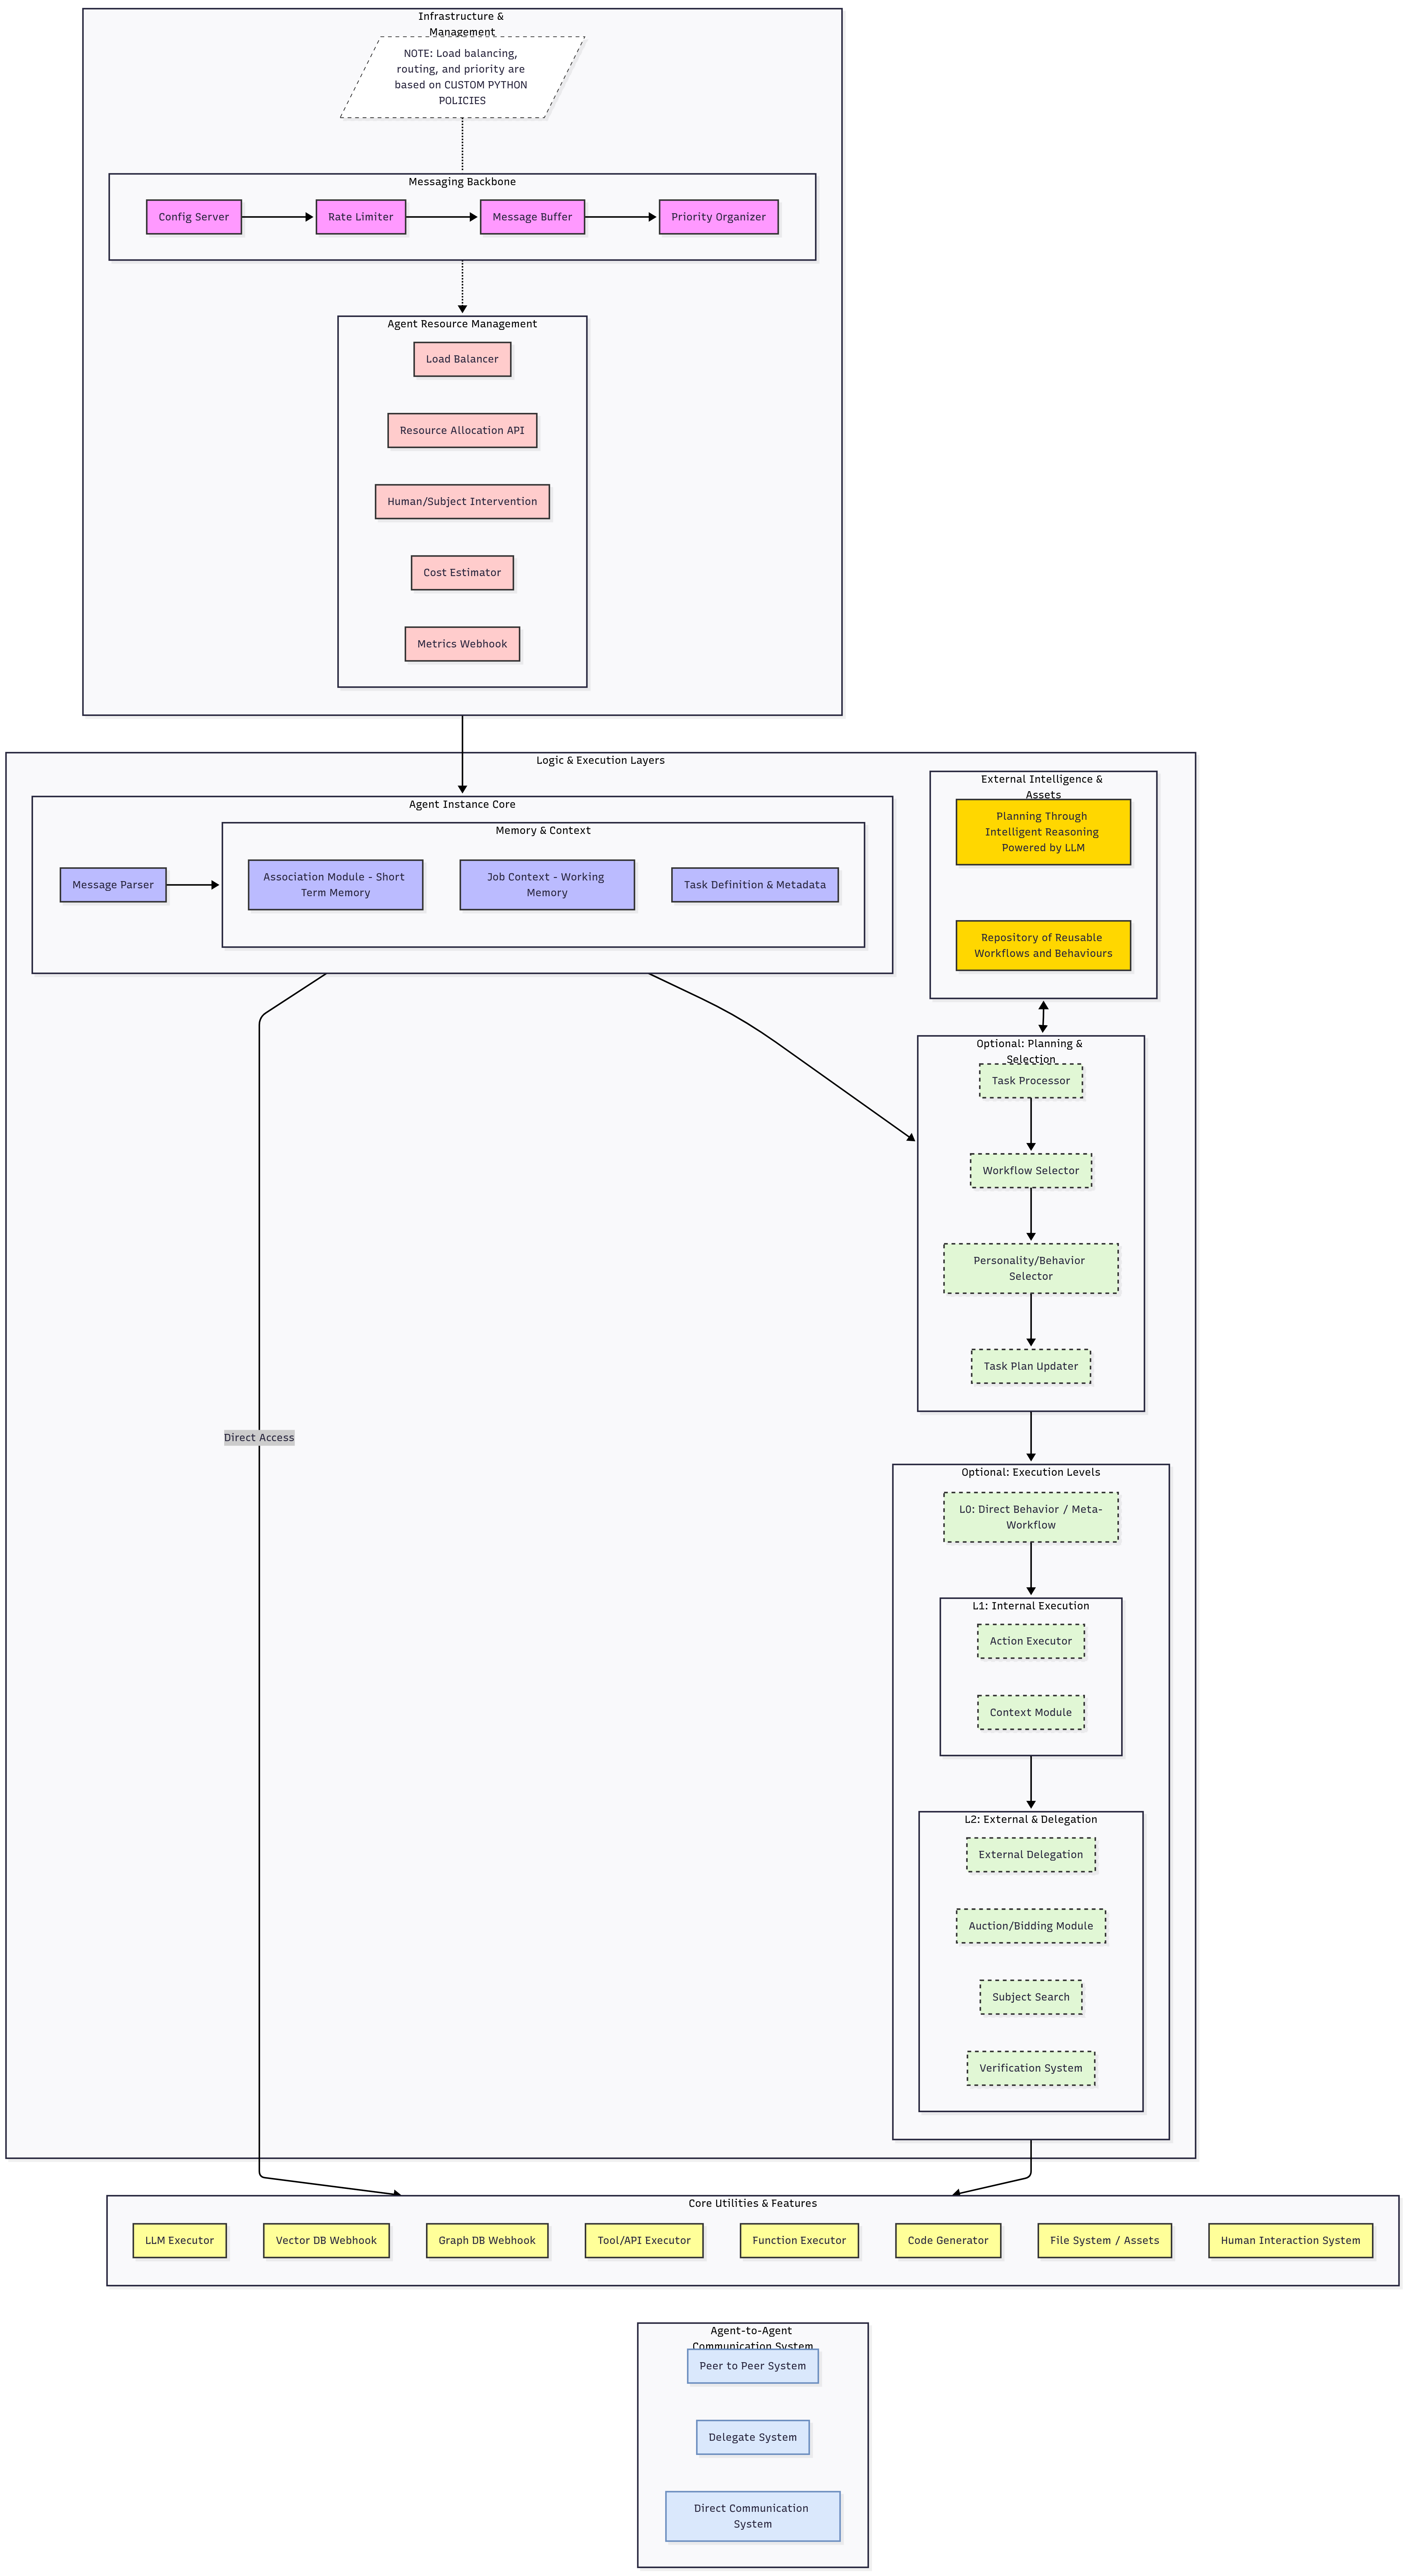

## Agents Communication
- `Direct (RESTful)`: Agents communicate via standard REST API calls. This point-to-point method is straightforward for Asynchronous interaction. Provide only async responses (Fire and Forget response).
- `Peer-to-Peer (NATS Mesh)`: Leveraging a NATS-based service mesh, agents form a decentralized network. This peer-to-peer (P2P) model allows for seamless discovery and resilient, high-performance messaging without a single point of failure. Provides both sync and async responses.
- `Delegated (Orchestrated)`: Messaging is routed through a centralized Delegation System. This intermediary manages request routing and provides synchronous responses. A key advantage of this architecture is built-in observability, as all traffic is persisted to a database for auditing and historical analysis.

### Agent Communication Matrix

| Mode | Communication Style | Waiting Behavior | Primary Benefit |
| :--- | :--- | :--- | :--- |
| **Direct** | Fire-and-Forget | **Non-blocking** | Low overhead and decoupled execution. |
| **Delegate** | Request-Response | **Blocking** | Guaranteed data consistency and a centralized audit trail. |
| **P2P** | Hybrid | **Flexible** | High performance and architectural agility across the mesh. |

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama etc) without changing your agent's core logic. The models which are hosted in AIOS as blocks or the 3rd party models like OpenAI/Gemini etc also can be accessed via the `agents_llm` library. As we will use `DSpy Library` for Agentic Programming, we have created a custom class to wrap the `agents_llm` library and provide a more user-friendly interface for model inference `AIOS_DSPy_LMs` custom class

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent.

### Core Data Structures
- **`AgentTask`**: Contains the `job_data` (payload) and metadata.
- **`AgentResult`**: Packages the output or error state.

### The `Context` Object
Every agent is initialized with a `Context`, providing communication handles:
1. **`p2p_manager`**: Synchronous or asynchronous peer-to-peer messaging. The Agent P2P Module enables decentralized, real-time communication between AI agents using WebSocket and HTTP. It supports direct messaging, API calls, file transfer, and remote task execution, making it ideal for distributed multi-agent coordination
2. **`delegator`**: Offloading tasks to specialized workers.
3. **`direct`**: Submitting tasks directly to other without central brokers

### Class Structure

In [ ]:
# sample_agent.py
import logging
import uuid
from typing import List, Optional

from core.agent_executor import AgentTask, AgentResult
from core.main import main
from core.agent_executor import Context

log = logging.getLogger(__name__)


class SampleAgent:

    def __init__(self, subject, context: Context) -> None:
        self.subject = subject
        self.context = context

    def get_muxer(self):
        return None

    def on_preprocess(self, task: AgentTask) -> Optional[List[AgentTask]]:

        text = task.job_data.get("text")
        if not text:
            log.warning(
                "Task %s has no 'text' in job_data, skipping.", task.task_id)
            return None

        return [task]

    def on_data(self, task: AgentTask) -> AgentResult:

        try:
            text = task.job_data["text"]
            out = text.upper()

            if self.context.subject_id == "uppercase-002":

                # agent P2P
                op_x = {}

                op_x = self.context.p2p_manager.send_and_wait_sync(
                    task.task_id, subject_id="uppercase-003",
                    task_data={"text": out + "World!"}
                )

                # using delegate
                op2 = self.context.delegator.submit_and_wait(
                    subject_id="uppercase-003", session_id=str(uuid.uuid4()), task_id=task.task_id, task_data={"text": out}
                )

                # agent direct (doesn't return the result to the caller)
                self.context.direct.submit(to="uppercase-003", session_id=str(uuid.uuid4()), task=task, job_data={
                    "text": "out " + "World!"
                })


                return AgentResult(
                    task_id=task.task_id,
                    job_output=op_x,
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

            else:

                return AgentResult(
                    task_id=task.task_id,
                    job_output={"text": out},
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

        except Exception as e:
            log.exception("Error processing task %s: %s", task.task_id, e)
            return AgentResult(
                task_id=task.task_id,
                is_error=True,
                error_data={"stage": "on_data", "message": str(e)},
            )


main(SampleAgent)


### FLOW
1. Use the Base Class Template shared above, and define(specific task) what the agent Class will do with the helps of AI Models and DSPy Library 
2. Use the communication entities to pass on the result of this agent to either next agents ro return the response back to user 
3. Build the docker and push to registry
4. Register the Agent to registry
5. Deploy the Agent Via Deployer
6. Do inference request to the First Agent/Agents

---

## 3. Case Study: Meeting Agenda Agents with Serial or Sequential Flow

The goal is to move a shared "state" through three distinct specialized agents.

### Flow Architecture
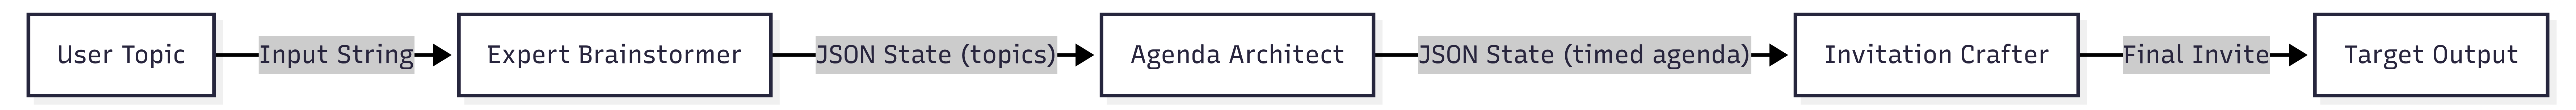

### Agent Roles & Constraints

#### A. Meeting Expert Brainstormer
- **Input**: `meeting_goal` (Raw Text).
- **DSPy Signature**: Processes the goal into a structured list of relevant topics.
- **Output**: Returns a JSON state containing the `meeting_goal` and `brainstormed_topics`.
- **Code**: [agent_meeting_expert_brainstormer.py](../../agent_codes/agent_meeting_expert_brainstormer.py)

#### B. Meeting Agenda Architect
- **Input**: Brainstormed topics.
- **Strict Constraint**: Must verify durations. If topics exceed 1 hour, it must prune or merge items.
- **Logic**: Sums durations ➡️ Compares to limit ➡️ Adjusts ➡️ Formats with timestamps.
- **Code**: [agent_meeting_agenda_architect.py](../../agent_codes/agent_meeting_agenda_architect.py)

#### C. Meeting Invitation Crafter
- **Input**: The timed agenda.
- **Role**: Context parsing. It pulls the goal, topics, and timings to generate a professional email/calendar invitation.
- **Code**: [agent_meeting_invitation_crafter.py](../../agent_codes/agent_meeting_invitation_crafter.py)

---

## 4. Execution Pipeline
1. **Build all the dockers**: Build the dockers using the bashscript provided i.e [build_meetingplanner_and_push.bash](../../agent_codes/build_meetingplanner_and_push.bash).
2. **Registration**: Agents are registered in the cluster via [register-agents.sh](../../agents_registration/1_serial_meeting_agend_agents/1_meeting-agenda-architect/register_agent.sh) for each agents.
3. **Deployment**: Containers are spun up using [deploy-agents.sh](../../agents_registration/1_serial_meeting_agend_agents/1_meeting-agenda-architect/deploy_agent.sh) for each agents.
4. **Trigger**: An initial `input` is sent to the **Brainstormer** via a API call, starting the chain reaction [inference_request.sh](../../agents_registration/1_serial_meeting_agend_agents/inference_request.sh)
5. **All in One**: Run [all.bash](../../agents_registration/1_serial_meeting_agend_agents/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash

In [1]:
%%bash
echo "$PWD"
cd ../../agents_registration/1_serial_meeting_agend_agents
echo "$PWD"
bash all.bash

/home/cognitifai/SHRIDHAR/AIOSV1/repositories/CosmosAI-AgentGrid/agentic-patterns/agent_guides/1_Sequential_Pattern
/home/cognitifai/SHRIDHAR/AIOSV1/repositories/CosmosAI-AgentGrid/agentic-patterns/agents_registration/1_serial_meeting_agend_agents
Sleeping for 30 seconds
~/SHRIDHAR/AIOSV1/repositories/CosmosAI-AgentGrid/agentic-patterns/agent_codes ~/SHRIDHAR/AIOSV1/repositories/CosmosAI-AgentGrid/agentic-patterns/agents_registration/1_serial_meeting_agend_agents
Building Docker image with AGENT=meeting-expert-brainstormer -> tag x.x.x.x:31280/agents/meeting-expert-brainstormer:latest


#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 768B 0.0s done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 1.9s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [ 1/10] FROM docker.io/library/python:3.11-slim@sha256:a3ab0b966bc4e91546a033e22093cb840908979487a9fc0e6e38295747e49ac0
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 30.77kB 2.0s done
#5 DONE 2.3s

#6 [ 4/10] RUN python3 --version
#6 CACHED

#7 [ 5/10] RUN pip3 install gepa==0.0.24
#7 CACHED

#8 [ 2/10] WORKDIR /app
#8 CACHED

#9 [ 3/10] COPY requirements.txt /app
#9 CACHED

#10 [ 6/10] RUN pip3 install -r requirements.txt
#10 CACHED

#11 [ 7/10] COPY . /app/
#11 DONE 0.2s

#12 [ 8/10] RUN if [ -f /app/.env ]; then grep -E '^(AIGRID_MASTER|AIGRID_INFERENCE_SERVER_URL)=' /app/.env > /app/.env.tmp && mv /app/.env.tmp /app/.env; fi
#12 DON

Built x.x.x.x:31280/agents/meeting-expert-brainstormer:latest
The push refers to repository [x.x.x.x:31280/agents/meeting-expert-brainstormer]


Get "https://x.x.x.x:31280/v2/": http: server gave HTTP response to HTTPS client


Building Docker image with AGENT=meeting-agenda-architect -> tag x.x.x.x:31280/agents/meeting-agenda-architect:latest


...

Building Docker image with AGENT=meeting-invitation-crafter -> tag x.x.x.x:31280/agents/meeting-invitation-crafter:latest


#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 768B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.4s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [ 1/10] FROM docker.io/library/python:3.11-slim@sha256:a3ab0b966bc4e91546a033e22093cb840908979487a9fc0e6e38295747e49ac0
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 18.26kB 0.0s done
#5 DONE 0.0s

#6 [ 5/10] RUN pip3 install gepa==0.0.24
#6 CACHED

#7 [ 6/10] RUN pip3 install -r requirements.txt
#7 CACHED

#8 [ 7/10] COPY . /app/
#8 CACHED

#9 [ 3/10] COPY requirements.txt /app
#9 CACHED

#10 [ 2/10] WORKDIR /app
#10 CACHED

#11 [ 4/10] RUN python3 --version
#11 CACHED

#12 [ 8/10] RUN if [ -f /app/.env ]; then grep -E '^(AIGRID_MASTER|AIGRID_INFERENCE_SERVER_URL)=' /app/.env > /app/.env.tmp && mv /app/.env.tmp /app/.env; fi
#12 CACHED

#13

Built x.x.x.x:31280/agents/meeting-invitation-crafter:latest
The push refers to repository [x.x.x.x:31280/agents/meeting-invitation-crafter]


Get "https://x.x.x.x:31280/v2/": http: server gave HTTP response to HTTPS client


~/SHRIDHAR/AIOSV1/repositories/CosmosAI-AgentGrid/agentic-patterns/agents_registration/1_serial_meeting_agend_agents


#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents executor-meeting-agenda-architect-77bb66b767-rnhrt -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### To check logs of pods

In [ ]:
%%bash
kubectl logs -f -n agents --tail 100 {POD_NAME} agent-core

#### Trigger the First agent

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/1_serial_meeting_agend_agents
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/1_serial_meeting_agend_agents
echo "$PWD"
bash remove-agents.sh